In [2]:
cat("Starting...")

#install.packages('Hmisc')
#install.packages('igraph')

library(Hmisc)
library(data.table)
library(terra)
library(lidR)
library(sf) # for buffering polygons, sf st_buffer is more permissive/less error prone than terra's buffer function
library(igraph) # for clustering
library(parallel) # for custom parallel processing
library(viridisLite) # for visualization
library(rstudioapi) # for automatic referencing

#install.packages('lasR', repos = 'https://r-lidar.r-universe.dev')
library(lasR) # for automatic referencing

#install.packages('RCSF')

cat("Packages installed!")

# Processing pipeline for Airborne Laser Scanning (ALS) 
#
# Produces standardized sets of digital terrain models (DTMs), digital surface
# models (DSMs), canopy height models (CHMs). The latter include rasterizations 
# of highest returns (chm_highest.tif), Delaunay-triangulation (chm_tin.tif), 
# and a locally adaptive spikefree algorithm that provides the most robust
# representation of top canopy height (chm_lspikefree.tif). The script also
# generates ancillary rasters for data quality control (pulse density, 
# scan angle, laser penetration), and outline shapefiles with data set 
# information. The script will run through a set of directories, process 
# multiple data sets and write them back to the output directory in the same 
# structure as in the input directory.
#
#
# DEVELOPERS: 
#
#   Fabian Jörg Fischer and Tommaso Jucker",
#
# ADDITIONAL CONTRIBUTORS TO DEVELOPMENT:",
#
#   Toby Jackson, Greg Vincent, Becky Morgan, Nicolas Labriere",
#   Andres Gonzalez-Moreno, Jerome Chave, Maxime Rejou-Mechain",
#
# CITATION:
#
#   Fischer, F. J., Jackson, T., Vincent, G., & Jucker, T. 2024.",
#   Robust characterisation of forest structure from airborne laser",
#   scanning — A systematic assessment and sample workflow for ecologists.",
#   Methods in Ecology and Evolution. https://doi.org/10.1111/2041-210"
#
# GENERAL TIPS FOR PROCESSING:
#
# 1. A metadata file (_metadata.csv) should be provided: this file will be used 
# to update information that can not be directly extracted from the scan. Key 
# information is: data citation/website/contact + coordinate reference system
# (EPSG code) + temporal acquisition range (minimum and maximum date). An 
# example is provided with the test data.
#
# 2. The folder structure in which las/laz files are stored should reflect 
# the structure of the underlying acquisitions, i.e., a folder should only 
# contain las/laz files that have been acquired at the same site and during the 
# same time period and in the same coordinate system. The pipeline will separate
# spatially distinct geo-units, but not check temporal ranges.
# 
# 3. None of the data files (laz/las) should have path lengths > 260 characters, 
# particularly when using multiple nested folders. Oddly, copy operations will 
# fail on Windows when this limit is exceeded, and there does not seem to be an 
# easy work-around.
#
# 4. The temporary folder (tmpdir) where data are processed should never be on a 
# synchronized drive or external hard drive, otherwise processing might be slow
#
# 5. When multi-processing, the maximum number of cores should be determined by 
# the number of physical cores, not logical ones. The script will check this and
# throw a warning if not true. However, this warning can be safely ignored in 
# some cases where (virtual machines, cloud processing)
#
#
#
# FOR MORE INFORMATION check _INFO_ files produced at the end of processing and
# the reference publication cited above.

#%%%%%%%%%%%%%%%%%%#
##### 1. Setup #####
#%%%%%%%%%%%%%%%%%%#
# use up-to-date versions of R version, R packages and LAStools! 
# update.packages()

# set working directory
path = "/home/jovyan/GCA/ALS_processing"
setwd(path)

# load helper functions
file_helperfunctions = "/home/jovyan/GCA/ALS_processing/ALS_processing_helperfunctions.R"
source(file_helperfunctions)

#%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%#
##### 2. Processing parameters (fixed tile size) #####
#%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%#
# standard processing script, using a fixed tile size
name_job = "gca"                               # overall job name, used for processing stats
type_file = "laz" # type of the files to be processed, needs to be exact (las, laz, LAS, etc.)
dir_dataset = "/home/jovyan/data/test"                    # folder that contains data sets
dir_processed =  "/home/jovyan/GCA/ALS_processing/output"      # folder where processed data sets should be saved
path_lastools = "" # folder to most recent lastools installation
tmpdir_processing = "/home/jovyan/GCA/ALS_processing/tmp"   #!!!: folder where processing occurs: files will be overwritten and should never be a folder that is synchronized or has slow read/write operations, i.e., no Dropbox folders, no OneDrive, and not an external hard drive
resolution = 1.0       # resolution of raster products (in m)
n_cores = 16         # number of cores for processing, keep 1-2 cores available for system operations
size_tile = 250        # retiling size
size_buffer = 50       # 25m - 50m, 50 m should be sufficient for any type of acquisition (25m may be too small for  ground point classification in sparse scans)
force.utm = "from_metadata"          # force reprojection of system into UTM (and meter) coordinates; necessary for all files that are registered in feet, otherwise output will be in feet
force.recompute = T    # force reprocessing; usually set to FALSE, useful when computation has been interrupted for external reasons (power cutofff) and needs to be restarted, because only unprocessed data subsets will be reprocessed
remove.vlr = T    # probably not necessary in most cases, but should be generally activated. The option leads to the removal of all vlrs AFTER the CRS of the first raster product is set. The CRS will be transmitted to all other raster products, so outputs will not be affected. By deactivating vlrs afterwards we prevent problems with further terra or lastools processing due to odd projection information, which sometimes causes an excess of warnings/errors (and shutdown of parallel processing) or blast2dem to fail
remove.evlr = T   # probably not necessary in most cases, but should be generally activated. The option leads to the removal of all evlrs AFTER the CRS of the first raster product is set. The CRS will be transmitted to all other raster products, so outputs will not be affected. By deactivating evlrs afterwards we prevent problems with further terra or lastools processing due to odd projection information, which sometimes causes an excess of warnings/errors (and shutdown of parallel processing) or blast2dem to fail
use.blast2dem = F # should be activated by default as it improves (or makes possible) TIN construction in very dense point clouds, but: not tested on Linux so far
type_architecture = "64" # only needed if 32bit Windows should be forced; 32 can be a bit more permissive, particularly for blast2dem

results = process.dataset(
  name_job = name_job
  , type_file = type_file
  , dir_dataset = dir_dataset
  , dir_processed = dir_processed
  , tmpdir_processing = tmpdir_processing
  , path_lastools = path_lastools
  , resolution = resolution
  , n_cores = n_cores
  , size_tile = size_tile
  , size_buffer = size_buffer
  , force.utm = force.utm
  , remove.vlr = remove.vlr
  , remove.evlr = remove.evlr
  , type_architecture = type_architecture 
  , use.blast2dem = use.blast2dem
  , patterns_skip = c() # skipping the processing of some folders
  , cleanup = T
)

Starting...Packages installed!System: Linux 
Architecture: 64 bit
Cores: 16 

1 | Processing: /home/jovyan/data/test/BCI_light  | Time: 13/06/2025 07h21 
Size buffer: 50 


Warning message in file.remove(f):
“cannot remove file '/tmp/RtmpGk3CTz/spat_18993dcdebf4_6297.vrt', reason 'No such file or directory'”



Remove old data from temporary directory and add new data
Copying files

Read in metadata
WARNING! No flight dates provided as part of metadata

Clean up data
las2las.initial OpenSource version!
4 files do not have a spatial index. Spatial indexing speeds up tile buffering and spatial queries drastically.
Files will be indexed on-the-fly. This will take some extra time now but will speed up everything later.
Amending file path
Amended file path returned

Check for spatial clusters in data
Defaulting to lidR. All files are considered as belonging to a single cluster

Found 1 clusters

PROCESSING CLUSTER 1 

Generating output from untreated point cloud

Generate initial classifications raster called...

processing file..

processing file ok

processing file..

processing file ok

processing file..

processing file ok

processing file..

processing file ok

processing file..

processing file ok

processing file..

processing file ok

processing file..

processing file ok

processing file

Original dataset already contains 151521 ground points. These points were reclassified as 'unclassified' before performing a new ground classification.

Original dataset already contains 151521 ground points. These points were reclassified as 'unclassified' before performing a new ground classification.

Original dataset already contains 129656 ground points. These points were reclassified as 'unclassified' before performing a new ground classification.

Original dataset already contains 129656 ground points. These points were reclassified as 'unclassified' before performing a new ground classification.

Original dataset already contains 220044 ground points. These points were reclassified as 'unclassified' before performing a new ground classification.

Original dataset already contains 220044 ground points. These points were reclassified as 'unclassified' before performing a new ground classification.

Original dataset already contains 189777 ground points. These points were reclassi

Amending file path and reindexing
Amended file path returned

Drop canopy heights above 125 
filter.height open source called...

Generate dtm_nooverhangs open source called...
Overall: [==========] 100% (8 threads)                      ======] 100% (1 threads)                    

Generate dtm_nooverhangs open source done!
Overall: [==========] 100% (16 threads)                      ==] 100% (1 threads)                        
filter.height open source done!
Amending file path and reindexing
Amended file path returned

Get summary stats
open source info called...
open source info done!
Computing summary statistics

...

Amending file path and reindexing
Amended file path returned
las2dem open source called...
>> dtm tin
las2dem open source done!

Generate make.dtm_custom open source done!
Warning! DTM extent is off and will be adjusted!

Create mask of DTM uncertainty 

DSM creation 

Creating highest point-based DSM 

Generate make.dsm_highest open source called...

Generate make.dsm_highest open source done!
Some CHM values are close to cutoff. These are potentially high noise / clouds that have not been removed

Creating TIN-based DSM 
las2dem open source called...
las2dem open source done!

Create normalized point cloud 
Amending file path and reindexing
Amended file path returned

Produce combined mask 

Produce synthesis 

create a polygon + metadata

add additional parameters

add computed scan information

information from masks

add additional information about the resulting landscape

add information about the processing

a little bit of path magic

other information

calculate size

write o

Warning message in x@ptr$write(filename, layer, filetype, insert[1], overwrite[1], :
“GDAL Message 1: Value 369152595.473999977 of field mingps of feature 0 not successfully written. Possibly due to too larger number with respect to field width”
Warning message in x@ptr$write(filename, layer, filetype, insert[1], overwrite[1], :
“GDAL Message 1: Value 369154989.25999999 of field maxgps of feature 0 not successfully written. Possibly due to too larger number with respect to field width”



convert to WGS84


Warning message in x@ptr$write(filename, layer, filetype, insert[1], overwrite[1], :
“GDAL Message 1: Value 369152595.473999977 of field mingps of feature 0 not successfully written. Possibly due to too larger number with respect to field width”
Warning message in x@ptr$write(filename, layer, filetype, insert[1], overwrite[1], :
“GDAL Message 1: Value 369154989.25999999 of field maxgps of feature 0 not successfully written. Possibly due to too larger number with respect to field width”



Wrapping up. Writing _INFO_ files


Warning message in plot.window(...):
“"fill_range" is not a graphical parameter”
Warning message in plot.xy(xy, type, ...):
“"fill_range" is not a graphical parameter”
Warning message in title(...):
“"fill_range" is not a graphical parameter”


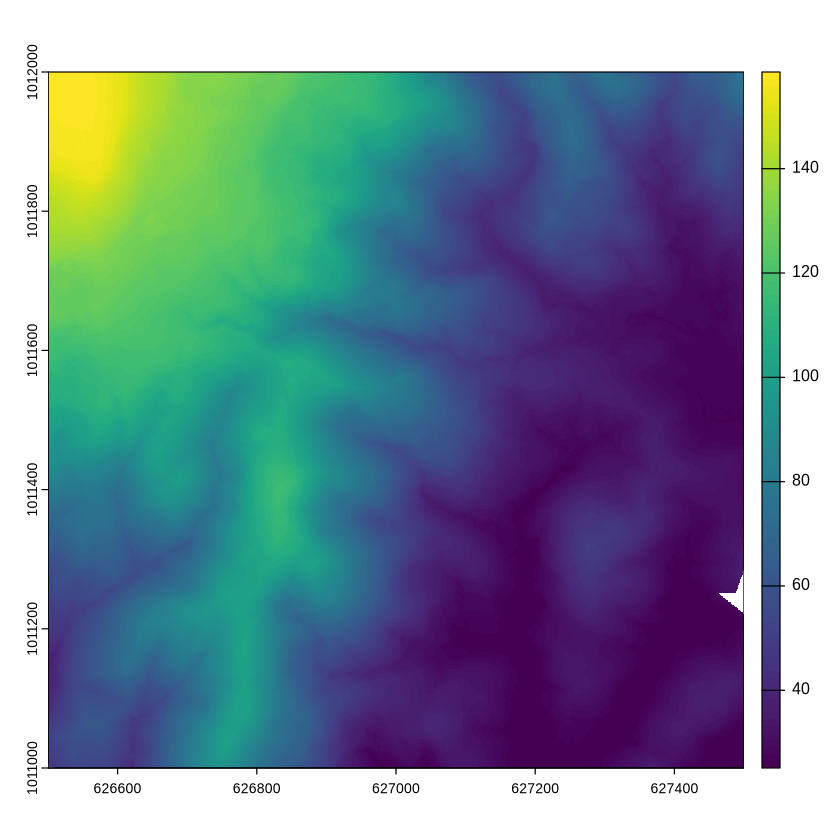

In [4]:
terra::plot(terra::rast("/home/jovyan/GCA/ALS_processing/output/BCI_light/dtm.tif"))

Warning message in plot.window(...):
“"fill_range" is not a graphical parameter”
Warning message in plot.xy(xy, type, ...):
“"fill_range" is not a graphical parameter”
Warning message in title(...):
“"fill_range" is not a graphical parameter”


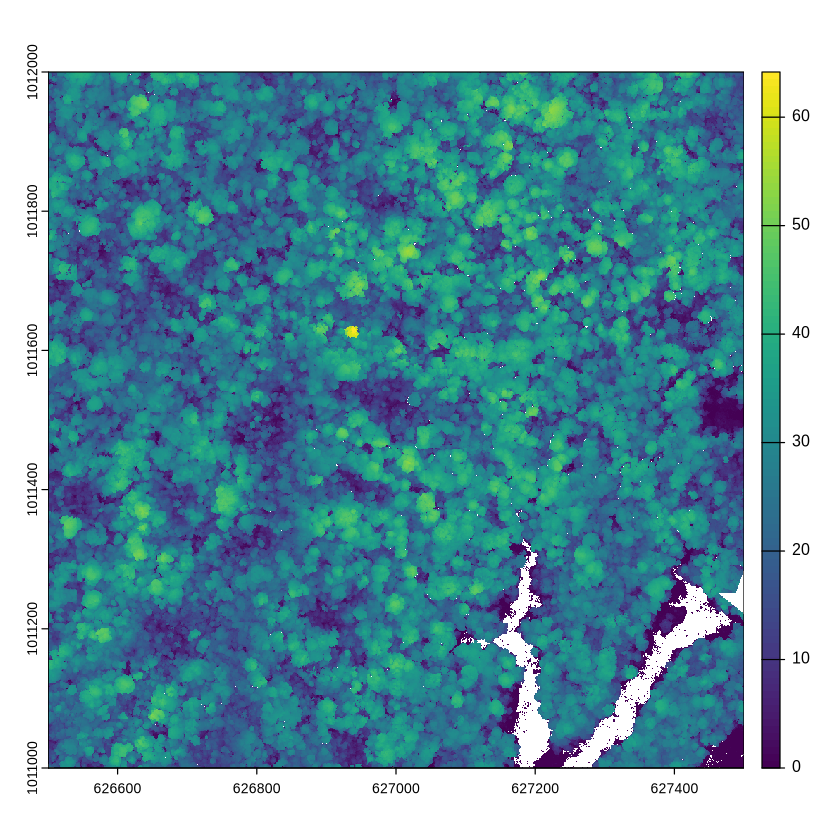

In [5]:
terra::plot(terra::rast("/home/jovyan/GCA/ALS_processing/output/BCI_light/chm_highest.tif"))

Warning message in plot.window(...):
“"fill_range" is not a graphical parameter”
Warning message in plot.xy(xy, type, ...):
“"fill_range" is not a graphical parameter”
Warning message in title(...):
“"fill_range" is not a graphical parameter”


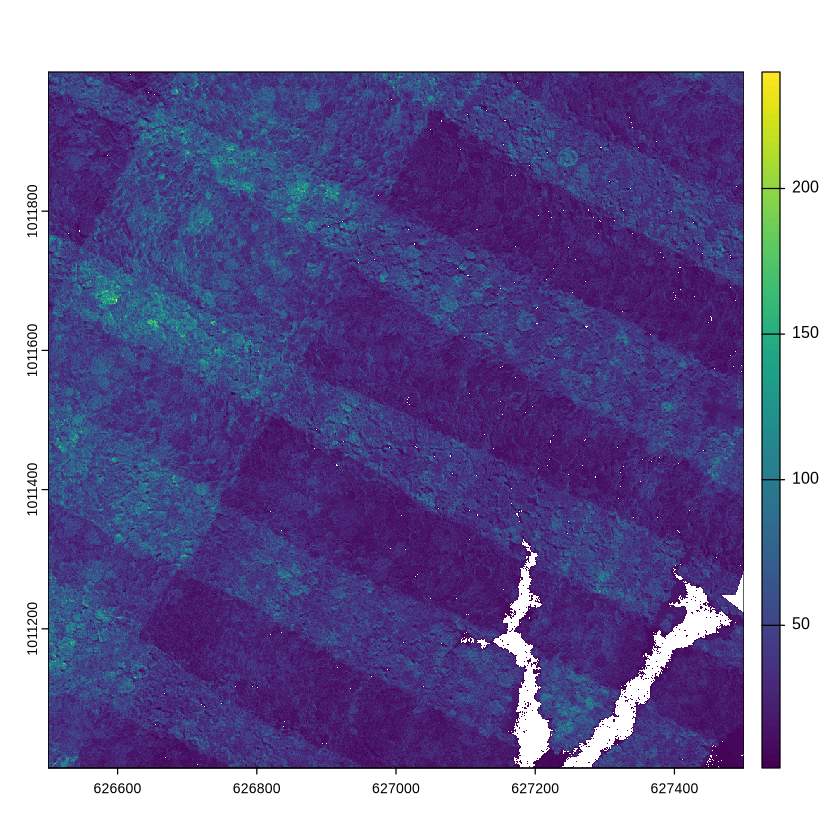

In [6]:
terra::plot(terra::rast("/home/jovyan/GCA/ALS_processing/output/BCI_light/pulsedensity.tif"))

Warning message in plot.window(...):
“"fill_range" is not a graphical parameter”
Warning message in plot.xy(xy, type, ...):
“"fill_range" is not a graphical parameter”
Warning message in title(...):
“"fill_range" is not a graphical parameter”


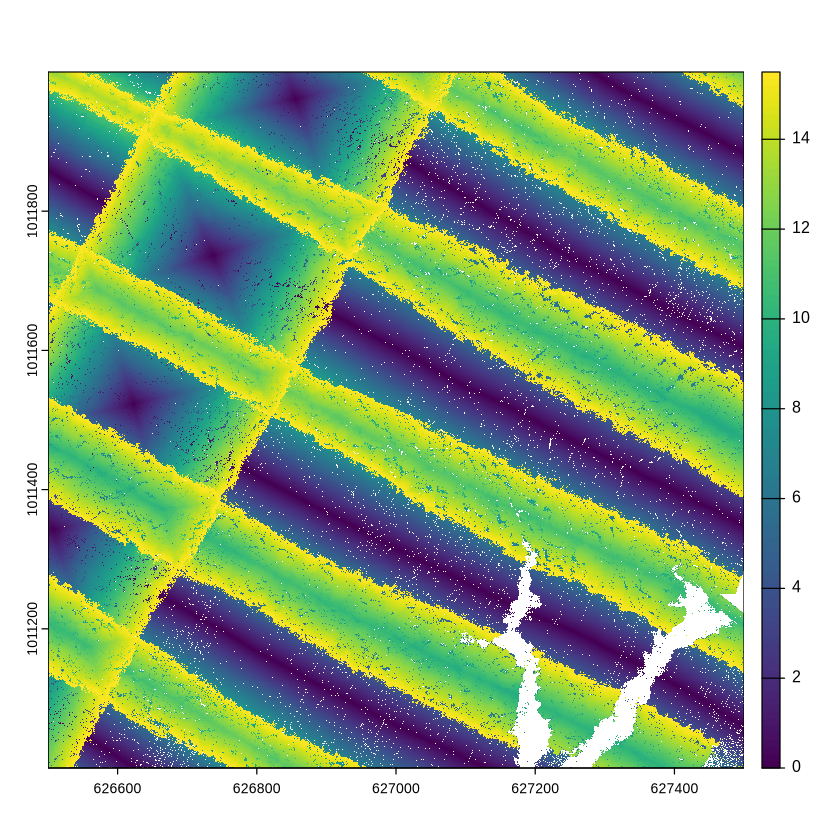

In [7]:
terra::plot(terra::rast("/home/jovyan/GCA/ALS_processing/output/BCI_light/scanangle_abs.tif"))